## Importing Libraries

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

## Stablish connection the the combined data of beijing air quality


In [23]:
candidate_paths = (
    Path('regions.csv'),
    Path('../PRSA_Data_20130301-20170228/regions.csv'),
    Path('PRSA_Data_20130301-20170228/regions.csv'),
)
data_path = next(path for path in candidate_paths if path.exists())
df = pd.read_csv(data_path)
df['datetime'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']])

pollutants = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']
meteorological = ['TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']
analysis_columns = pollutants + meteorological
df[analysis_columns] = df[analysis_columns].apply(pd.to_numeric, errors='coerce')

## Pollutants and Weather Measurements

This compares the linear relationships among pollutant concentrations and weather measurements.

       PM2.5   PM10    SO2    NO2     CO     O3   TEMP   PRES   DEWP   RAIN  \
PM2.5  1.000  0.884  0.482  0.667  0.790 -0.150 -0.131  0.019  0.115 -0.014   
PM10   0.884  1.000  0.463  0.652  0.702 -0.111 -0.096 -0.018  0.070 -0.027   
SO2    0.482  0.463  1.000  0.499  0.536 -0.165 -0.322  0.223 -0.267 -0.040   
NO2    0.667  0.652  0.499  1.000  0.705 -0.472 -0.278  0.174 -0.032 -0.044   
CO     0.790  0.702  0.536  0.705  1.000 -0.313 -0.326  0.188 -0.057 -0.013   
O3    -0.150 -0.111 -0.165 -0.472 -0.313  1.000  0.595 -0.446  0.312  0.023   
TEMP  -0.131 -0.096 -0.322 -0.278 -0.326  0.595  1.000 -0.813  0.820  0.038   
PRES   0.019 -0.018  0.223  0.174  0.188 -0.446 -0.813  1.000 -0.750 -0.061   
DEWP   0.115  0.070 -0.267 -0.032 -0.057  0.312  0.820 -0.750  1.000  0.086   
RAIN  -0.014 -0.027 -0.040 -0.044 -0.013  0.023  0.038 -0.061  0.086  1.000   
WSPM  -0.272 -0.184 -0.109 -0.400 -0.298  0.296  0.033  0.065 -0.297  0.021   

        WSPM  
PM2.5 -0.272  
PM10  -0.184  
SO2   

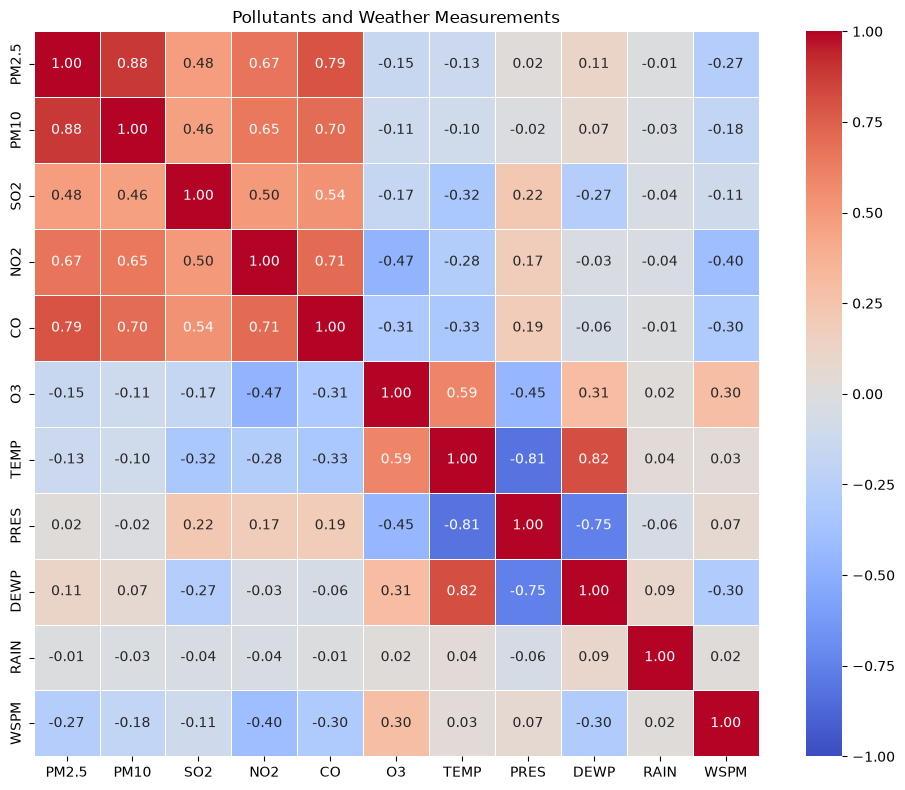

Heatmap saved to: ..\PRSA_Data_20130301-20170228\pearson_correlation_heatmap.png


In [24]:
pearson_corr = df[analysis_columns].corr(method='pearson')
print(pearson_corr.round(3))

plt.figure(figsize=(10, 8))
sns.heatmap(
    pearson_corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5
)
plt.title('Pollutants and Weather Measurements')
plt.tight_layout()
heatmap_path = data_path.parent / 'pearson_correlation_heatmap.png'
plt.savefig(heatmap_path, dpi=150)
plt.show()
print(f'Heatmap saved to: {heatmap_path}')

## Ranked Pollutants and Weather Measurements

This compares the ranked relationships among pollutant concentrations and weather measurements.

       PM2.5   PM10    SO2    NO2     CO     O3   TEMP   PRES   DEWP   RAIN  \
PM2.5  1.000  0.891  0.500  0.658  0.837 -0.254 -0.024 -0.070  0.241 -0.020   
PM10   0.891  1.000  0.498  0.643  0.732 -0.212 -0.018 -0.077  0.150 -0.080   
SO2    0.500  0.498  1.000  0.527  0.565 -0.213 -0.360  0.291 -0.342 -0.151   
NO2    0.658  0.643  0.527  1.000  0.741 -0.614 -0.270  0.184 -0.018 -0.069   
CO     0.837  0.732  0.565  0.741  1.000 -0.450 -0.222  0.117  0.093  0.009   
O3    -0.254 -0.212 -0.213 -0.614 -0.450  1.000  0.582 -0.438  0.247 -0.010   
TEMP  -0.024 -0.018 -0.360 -0.270 -0.222  0.582  1.000 -0.819  0.817  0.039   
PRES  -0.070 -0.077  0.291  0.184  0.117 -0.438 -0.819  1.000 -0.757 -0.081   
DEWP   0.241  0.150 -0.342 -0.018  0.093  0.247  0.817 -0.757  1.000  0.177   
RAIN  -0.020 -0.080 -0.151 -0.069  0.009 -0.010  0.039 -0.081  0.177  1.000   
WSPM  -0.329 -0.251 -0.066 -0.441 -0.389  0.427  0.102  0.036 -0.237 -0.023   

        WSPM  
PM2.5 -0.329  
PM10  -0.251  
SO2   

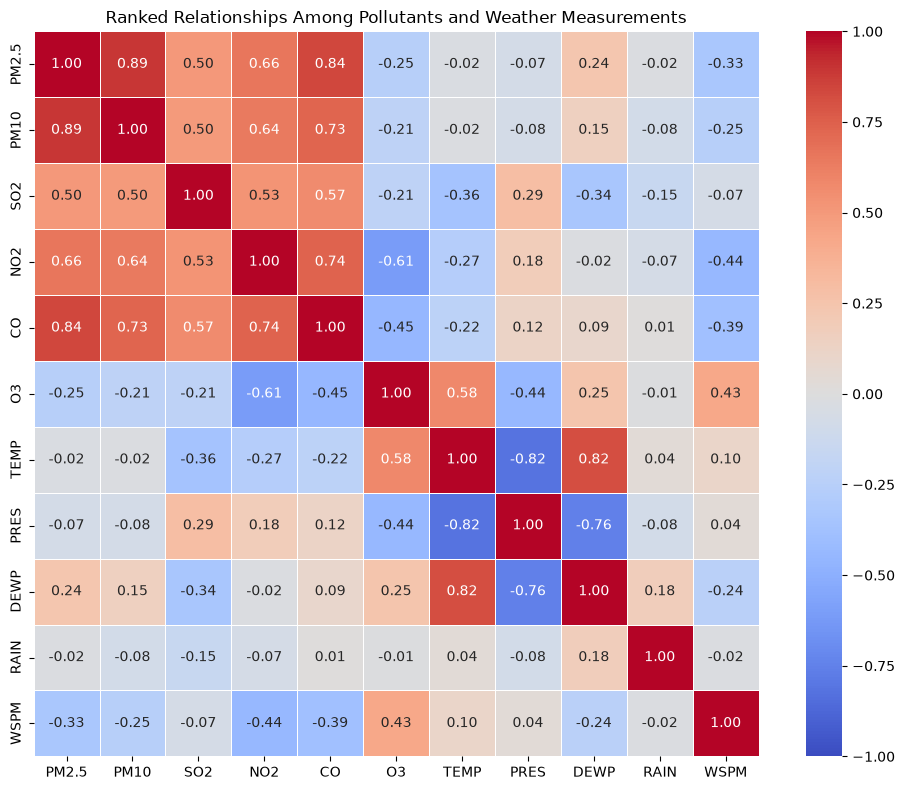

Heatmap saved to: ..\PRSA_Data_20130301-20170228\spearman_correlation_heatmap.png


In [26]:
spearman_corr = df[analysis_columns].corr(method='spearman')
print(spearman_corr.round(3))

plt.figure(figsize=(10, 8))
sns.heatmap(
    spearman_corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5
)
plt.title('Ranked Relationships Among Pollutants and Weather Measurements')
plt.tight_layout()
spearman_heatmap_path = data_path.parent / 'spearman_correlation_heatmap.png'
plt.savefig(spearman_heatmap_path, dpi=150)
plt.show()
print(f'Heatmap saved to: {spearman_heatmap_path}')

## Relationships between pollutans and weather measurements

This identifies the strongest relationships among pollutants and weather measurements.

variable_1 variable_2  correlation
     PM2.5       PM10        0.884
      TEMP       DEWP        0.820
      TEMP       PRES       -0.813
     PM2.5         CO        0.790
      PRES       DEWP       -0.750
       NO2         CO        0.705
      PM10         CO        0.702
     PM2.5        NO2        0.667
      PM10        NO2        0.652
        O3       TEMP        0.595


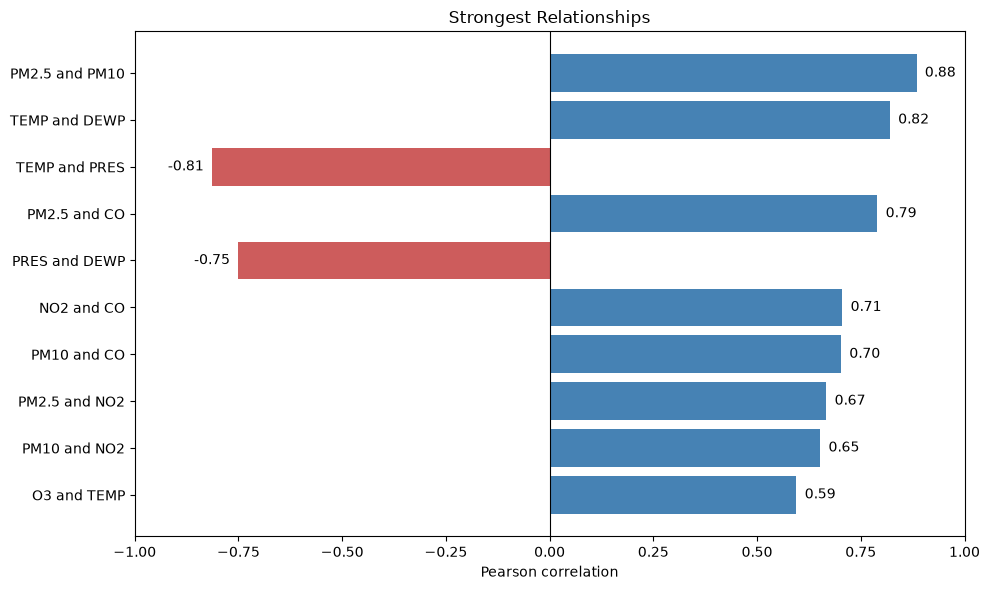

Chart saved to: ..\PRSA_Data_20130301-20170228\strongest_relationships.png


In [30]:
upper_triangle = np.triu_indices_from(pearson_corr, k=1)
strongest_pairs = pd.DataFrame({
    'variable_1': pearson_corr.index[upper_triangle[0]],
    'variable_2': pearson_corr.columns[upper_triangle[1]],
    'correlation': pearson_corr.to_numpy()[upper_triangle]
})
strongest_pairs['absolute_correlation'] = strongest_pairs['correlation'].abs()
strongest_pairs = strongest_pairs.sort_values(
    'absolute_correlation', ascending=False
).head(10)
strongest_pairs['relationship'] = strongest_pairs['variable_1'] + ' and ' + strongest_pairs['variable_2']
print(strongest_pairs[['variable_1', 'variable_2', 'correlation']].round(3).to_string(index=False))

plt.figure(figsize=(10, 6))
colors = ['steelblue' if value >= 0 else 'indianred' for value in strongest_pairs['correlation']]
plt.barh(strongest_pairs['relationship'][::-1], strongest_pairs['correlation'][::-1], color=colors[::-1])
plt.axvline(0, color='black', linewidth=0.8)
for index, value in enumerate(strongest_pairs['correlation'][::-1]):
    offset = 0.02 if value >= 0 else -0.02
    alignment = 'left' if value >= 0 else 'right'
    plt.text(value + offset, index, f'{value:.2f}', va='center', ha=alignment)
plt.xlabel('Pearson correlation')
plt.title('Strongest Relationships')
plt.xlim(-1, 1)
plt.tight_layout()
strongest_relationships_path = data_path.parent / 'strongest_relationships.png'
plt.savefig(strongest_relationships_path, dpi=150)
plt.show()
print(f'Chart saved to: {strongest_relationships_path}')

## PM2.5 and Other Pollutants by Station

This compares PM2.5 with the other pollutants separately for each monitoring station.

                PM10    SO2    NO2     CO     O3
station                                         
Aotizhongxin   0.879  0.481  0.685  0.785 -0.161
Changping      0.864  0.457  0.674  0.767 -0.098
Dingling       0.868  0.475  0.718  0.803 -0.101
Dongsi         0.890  0.547  0.693  0.802 -0.138
Guanyuan       0.895  0.493  0.692  0.799 -0.141
Gucheng        0.855  0.459  0.695  0.768 -0.187
Huairou        0.883  0.410  0.655  0.802 -0.064
Nongzhanguan   0.904  0.533  0.690  0.814 -0.189
Shunyi         0.900  0.462  0.644  0.782 -0.135
Tiantan        0.893  0.397  0.663  0.800 -0.167
Wanliu         0.882  0.497  0.671  0.750 -0.156
Wanshouxigong  0.890  0.502  0.697  0.814 -0.191


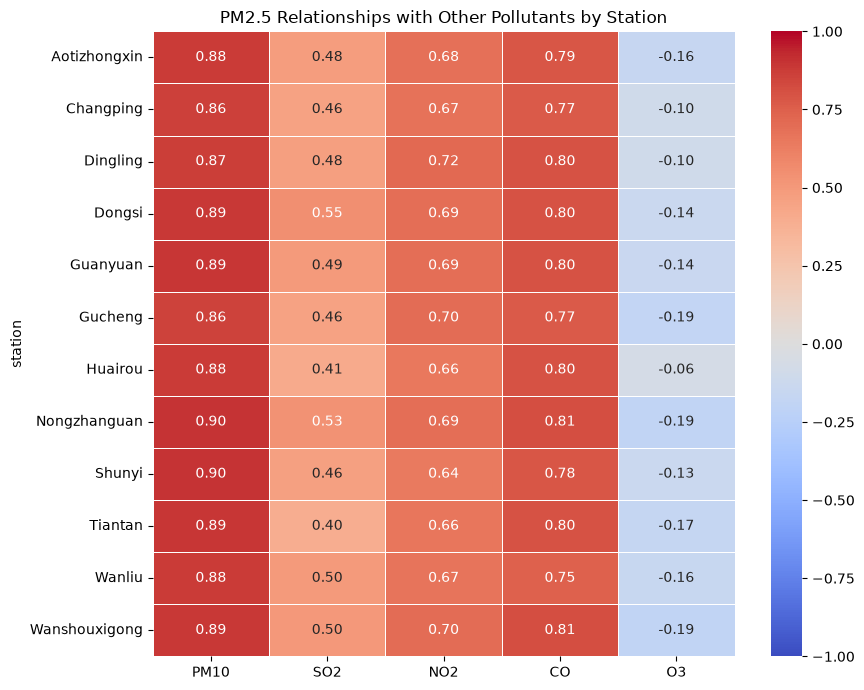

Heatmap saved to: ..\PRSA_Data_20130301-20170228\pm25_station_correlation_heatmap.png


In [28]:
station_corr = (
    df.groupby('station')[pollutants]
    .corr()['PM2.5']
    .unstack(level=1)
    .drop(columns='PM2.5')
)
print(station_corr.round(3))

plt.figure(figsize=(9, 7))
sns.heatmap(
    station_corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5
)
plt.title('PM2.5 Relationships with Other Pollutants by Station')
plt.tight_layout()
station_heatmap_path = data_path.parent / 'pm25_station_correlation_heatmap.png'
plt.savefig(station_heatmap_path, dpi=150)
plt.show()
print(f'Heatmap saved to: {station_heatmap_path}')